In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Imports

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset

In [4]:
zip_path = "/content/drive/MyDrive/GANS ASS1/archive (4).zip"

In [5]:
import zipfile
import os
extract_path = "/content/dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction Dn")

Extraction Dn


In [6]:
!ls /content/dataset

AbdomenCT  BreastMRI  ChestCT  CXR  Hand  HeadCT


In [8]:
def load_dataset(path, batch_size=128, img_size=(64, 64)):
    dataset = tf.keras.preprocessing.image_dataset_from_directory(
        path,
        image_size=img_size,
        batch_size=batch_size,
        shuffle=True
    )
    dataset = dataset.map(lambda x, y: (x / 255.0, x / 255.0))
    return dataset

In [9]:
data_path = "/content/dataset"
df = load_dataset(data_path)

Found 58954 files belonging to 6 classes.


In [10]:
for batch in df.take(1):
    input_shape = batch[0].shape[1:]

print("Input shape:", input_shape)

Input shape: (64, 64, 3)


# Autoencoder Model

In [13]:
def build_autoencoder(input_shape, latent_dim=64):
    # Encoder
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(inputs)
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, name="latent")(x)
    encoder = Model(inputs, latent, name="encoder")
    # Decoder
    latent_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(16*16*64, activation="relu")(latent_inputs)
    x = layers.Reshape((16, 16, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    outputs = layers.Conv2D(3, 3, activation="sigmoid", padding="same")(x)
    decoder = Model(latent_inputs, outputs, name="decoder")
    outputs = decoder(encoder(inputs))
    ae = Model(inputs, outputs, name="autoencoder")
    return ae, encoder, decoder
ae, ae_encoder, ae_decoder = build_autoencoder(input_shape)

In [16]:
ae.compile(optimizer="adam", loss="mse")
ae_history = ae.fit(df, epochs=10)

Epoch 1/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - loss: 0.0036
Epoch 2/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0034
Epoch 3/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0034
Epoch 4/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.0033
Epoch 5/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.0033
Epoch 6/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.0032
Epoch 7/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0032
Epoch 8/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0032
Epoch 9/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0031
Epoch 10/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0031


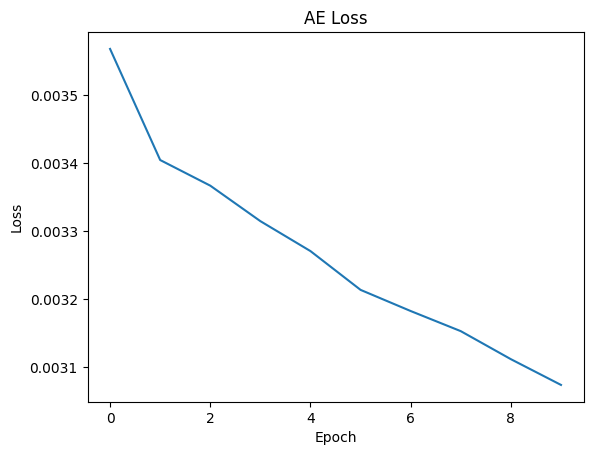

In [17]:
plt.plot(ae_history.history['loss'])
plt.title("AE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Variational Autoencoder (VAE)

In [33]:
tf.keras.backend.clear_session()
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon
def build_vae(input_shape, latent_dim=64):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")
    latent_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(16*16*64, activation="relu")(latent_inputs)
    x = layers.Reshape((16, 16, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    outputs = layers.Conv2D(3, 3, activation="sigmoid", padding="same")(x)
    decoder = Model(latent_inputs, outputs, name="decoder")
    class VAE(Model):
        def __init__(self, encoder, decoder, **kwargs):
            super().__init__(**kwargs)
            self.encoder = encoder
            self.decoder = decoder
        def call(self, inputs):
            z_mean, z_log_var, z = self.encoder(inputs)
            return self.decoder(z)
        def train_step(self, data):
            if isinstance(data, tuple):
                data = data[0]
            with tf.GradientTape() as tape:
                z_mean, z_log_var, z = self.encoder(data)
                reconstruction = self.decoder(z)
                reconstruction_loss = tf.reduce_mean(
                    tf.reduce_sum(tf.square(data - reconstruction), axis=[1,2,3])
                )
                kl_loss = -0.5 * tf.reduce_mean(
                    tf.reduce_sum(
                        1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                        axis=1
                    )
                )
                total_loss = reconstruction_loss + kl_loss
            grads = tape.gradient(total_loss, self.trainable_weights)
            self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
            return {
                "loss": total_loss,
                "reconstruction_loss": reconstruction_loss,
                "kl_loss": kl_loss,
            }

    vae = VAE(encoder, decoder)

    return vae, encoder, decoder




In [34]:
vae, vae_encoder, vae_decoder = build_vae(input_shape)
vae.compile(optimizer="adam")
history = vae.fit(df, epochs=10)

Epoch 1/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - kl_loss: 36.9034 - loss: 160.8745 - reconstruction_loss: 123.9711
Epoch 2/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - kl_loss: 35.7599 - loss: 127.2675 - reconstruction_loss: 91.5077
Epoch 3/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - kl_loss: 42.4643 - loss: 137.9468 - reconstruction_loss: 95.4825
Epoch 4/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - kl_loss: 41.8949 - loss: 134.7678 - reconstruction_loss: 92.8730
Epoch 5/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - kl_loss: 34.2534 - loss: 109.0430 - reconstruction_loss: 74.7896
Epoch 6/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - kl_loss: 39.3300 - loss: 127.5497 - reconstruction_loss: 88.2197
Epoch 7/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - kl_loss: 33.0489 - loss: 104.8925 - reconstruction_loss: 71.8435
Epoch 8/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - kl_loss: 38.7471 - loss: 114.0020 - reconstruction_loss: 75.2550
Epoch 9/10
461/461 ━━━━━━━━━━━━

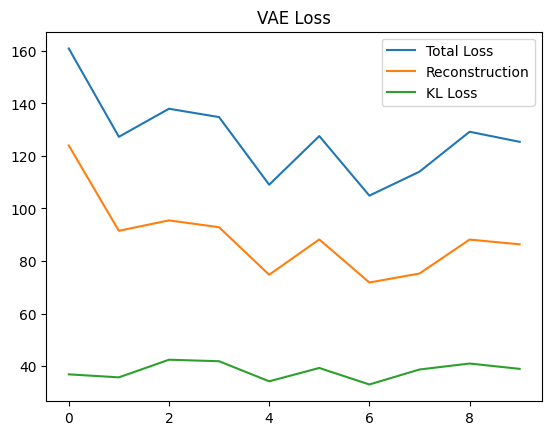

In [35]:
plt.plot(history.history['loss'], label="Total Loss")
plt.plot(history.history['reconstruction_loss'], label="Reconstruction")
plt.plot(history.history['kl_loss'], label="KL Loss")
plt.legend()
plt.title("VAE Loss")
plt.show()

***Training is working, but not well optimized***

# Trial 1 for enhancements

In [36]:
tf.keras.backend.clear_session()
EPOCHS = 30              # increased from 10
LATENT_DIM = 128         # increased from 64
LEARNING_RATE = 0.0005   # reduced for stability
BETA = 0.001             # KL weighting (beta-VAE)
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon
def build_vae(input_shape):
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(inputs)
    x = tf.keras.layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)
    x = tf.keras.layers.Flatten()(x)
    z_mean = tf.keras.layers.Dense(LATENT_DIM)(x)
    z_log_var = tf.keras.layers.Dense(LATENT_DIM)(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = tf.keras.Model(inputs, [z_mean, z_log_var, z])
    # Decoder
    latent_inputs = tf.keras.layers.Input(shape=(LATENT_DIM,))
    x = tf.keras.layers.Dense(8*8*128, activation="relu")(latent_inputs)
    x = tf.keras.layers.Reshape((8, 8, 128))(x)
    x = tf.keras.layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    outputs = tf.keras.layers.Conv2D(3, 3, activation="sigmoid", padding="same")(x)
    decoder = tf.keras.Model(latent_inputs, outputs)
    class VAE(tf.keras.Model):
        def __init__(self, encoder, decoder):
            super().__init__()
            self.encoder = encoder
            self.decoder = decoder
        def call(self, inputs):
            z_mean, z_log_var, z = self.encoder(inputs)
            return self.decoder(z)
        def train_step(self, data):
            if isinstance(data, tuple):
                data = data[0]
            with tf.GradientTape() as tape:
                z_mean, z_log_var, z = self.encoder(data)
                reconstruction = self.decoder(z)
                reconstruction_loss = tf.reduce_mean(
                    tf.reduce_sum(tf.square(data - reconstruction), axis=[1,2,3])
                ) / (64*64*3)
                kl_loss = -0.5 * tf.reduce_mean(
                    tf.reduce_sum(
                        1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                        axis=1
                    )
                )
                total_loss = reconstruction_loss + BETA * kl_loss
            grads = tape.gradient(total_loss, self.trainable_weights)
            self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

            return {
                "loss": total_loss,
                "reconstruction_loss": reconstruction_loss,
                "kl_loss": kl_loss,
            }
    vae = VAE(encoder, decoder)
    return vae

Epoch 1/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - kl_loss: 5.3972 - loss: 0.0371 - reconstruction_loss: 0.0317
Epoch 2/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - kl_loss: 6.6957 - loss: 0.0296 - reconstruction_loss: 0.0229
Epoch 3/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - kl_loss: 7.8130 - loss: 0.0279 - reconstruction_loss: 0.0201
Epoch 4/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - kl_loss: 7.6448 - loss: 0.0274 - reconstruction_loss: 0.0198
Epoch 5/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - kl_loss: 7.3130 - loss: 0.0244 - reconstruction_loss: 0.0171
Epoch 6/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - kl_loss: 7.2354 - loss: 0.0233 - reconstruction_loss: 0.0161
Epoch 7/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - kl_loss: 7.4913 - loss: 0.0253 - reconstruction_loss: 0.0179
Epoch 8/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - kl_loss: 6.7510 - loss: 0.0218 - reconstruction_loss: 0.0151
Epoch 9/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - kl_loss:

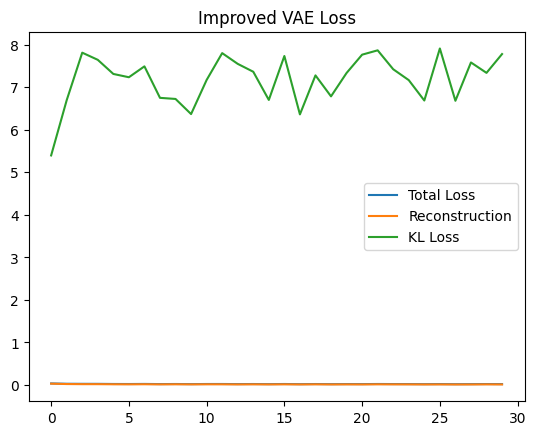

In [37]:
vae = build_vae(input_shape)
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
vae.compile(optimizer=optimizer)
history = vae.fit(df, epochs=EPOCHS)
plt.plot(history.history['loss'], label="Total Loss")
plt.plot(history.history['reconstruction_loss'], label="Reconstruction")
plt.plot(history.history['kl_loss'], label="KL Loss")
plt.legend()
plt.title("Improved VAE Loss")
plt.show()

In [38]:
tf.keras.backend.clear_session()
EPOCHS = 30
LATENT_DIM = 64
LEARNING_RATE = 0.0005
BETA = 1.0
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon
def build_vae(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)
    z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
    z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")
    latent_inputs = layers.Input(shape=(LATENT_DIM,))
    x = layers.Dense(16*16*64, activation="relu")(latent_inputs)
    x = layers.Reshape((16, 16, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    outputs = layers.Conv2D(3, 3, activation="sigmoid", padding="same")(x)
    decoder = Model(latent_inputs, outputs, name="decoder")
    class VAE(Model):
        def __init__(self, encoder, decoder):
            super().__init__()
            self.encoder = encoder
            self.decoder = decoder

        def call(self, inputs):
            z_mean, z_log_var, z = self.encoder(inputs)
            return self.decoder(z)
        def train_step(self, data):
            if isinstance(data, tuple):
                data = data[0]
            with tf.GradientTape() as tape:
                z_mean, z_log_var, z = self.encoder(data)
                reconstruction = self.decoder(z)
                reconstruction_loss = tf.reduce_mean(
                    tf.reduce_sum(tf.square(data - reconstruction), axis=[1,2,3])
                )

                kl_loss = -0.5 * tf.reduce_mean(
                    tf.reduce_sum(
                        1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                        axis=1
                    )
                )
                total_loss = reconstruction_loss + BETA * kl_loss
            grads = tape.gradient(total_loss, self.trainable_weights)
            self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

            return {
                "loss": total_loss,
                "reconstruction_loss": reconstruction_loss,
                "kl_loss": kl_loss,
            }
    vae = VAE(encoder, decoder)
    return vae

# Trial 2 for enhancements

Epoch 1/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - kl_loss: 26.7136 - loss: 322.6984 - reconstruction_loss: 295.9848
Epoch 2/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - kl_loss: 39.5730 - loss: 170.7986 - reconstruction_loss: 131.2256
Epoch 3/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - kl_loss: 41.3564 - loss: 147.9222 - reconstruction_loss: 106.5658
Epoch 4/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - kl_loss: 42.7375 - loss: 139.4881 - reconstruction_loss: 96.7506
Epoch 5/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - kl_loss: 41.1163 - loss: 138.0403 - reconstruction_loss: 96.9241
Epoch 6/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - kl_loss: 43.1697 - loss: 133.4502 - reconstruction_loss: 90.2805
Epoch 7/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - kl_loss: 43.4067 - loss: 125.8928 - reconstruction_loss: 82.4861
Epoch 8/30
461/461 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - kl_loss: 43.3982 - loss: 121.7002 - reconstruction_loss: 78.3020
Epoch 9/30
461/461 ━━━━━━━━━━

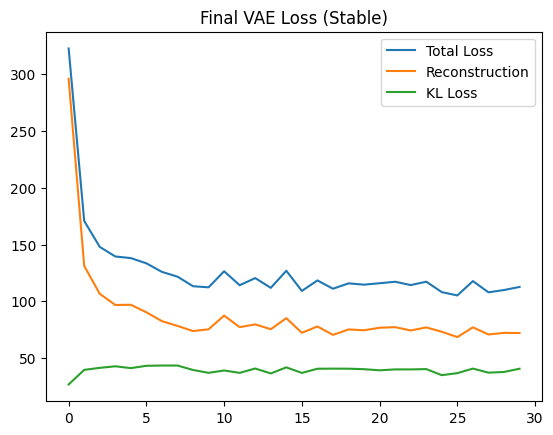

In [39]:
vae = build_vae(input_shape)
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
vae.compile(optimizer=optimizer)
history = vae.fit(df, epochs=EPOCHS)
plt.plot(history.history['loss'], label="Total Loss")
plt.plot(history.history['reconstruction_loss'], label="Reconstruction")
plt.plot(history.history['kl_loss'], label="KL Loss")
plt.legend()
plt.title("Final VAE Loss (Stable)")
plt.show()

Removed:
Reconstruction normalization (it killed learning)

# Latent Space Visualization

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  


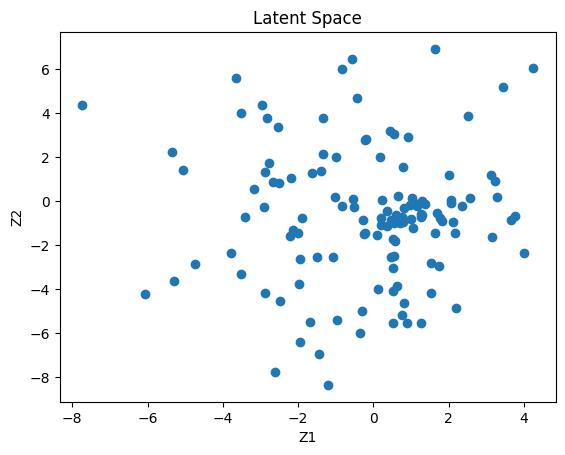

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step  


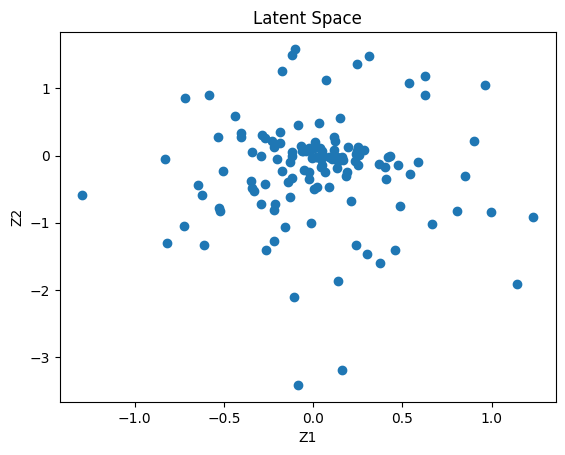

In [43]:
def plot_latent_space(encoder, dataset):
    for batch in dataset.take(1):
        images = batch[0]
    z = encoder.predict(images)
    if isinstance(z, list):
        z = z[0]
    plt.scatter(z[:, 0], z[:, 1])
    plt.title("Latent Space")
    plt.xlabel("Z1")
    plt.ylabel("Z2")
    plt.show()
plot_latent_space(ae_encoder, df)
plot_latent_space(vae_encoder, df)

VAE learned a better structured latent space

# Reconstruction analysis

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


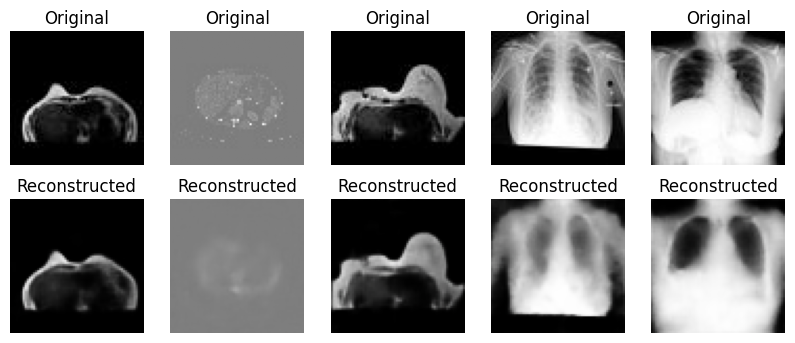

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


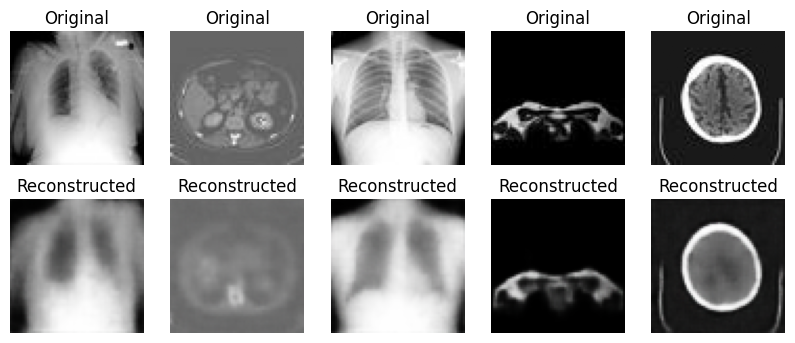

In [40]:
def plot_reconstruction(model, dataset):
    for batch in dataset.take(1):
        images = batch[0]
    reconstructed = model.predict(images)
    plt.figure(figsize=(10, 4))
    for i in range(5):
        # Original
        plt.subplot(2, 5, i+1)
        plt.imshow(images[i])
        plt.title("Original")
        plt.axis("off")
        # Reconstructed
        plt.subplot(2, 5, i+6)
        plt.imshow(reconstructed[i])
        plt.title("Reconstructed")
        plt.axis("off")
    plt.show()
plot_reconstruction(ae, df)
plot_reconstruction(vae, df)

# Generate Samples

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 615ms/step


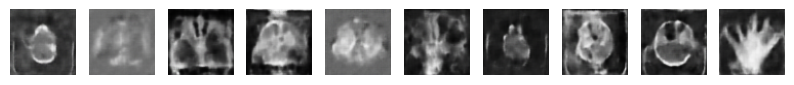

In [41]:
z = np.random.normal(size=(10, 64))
generated = vae_decoder.predict(z)
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(generated[i])
    plt.axis("off")
plt.show()

# Denoising

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


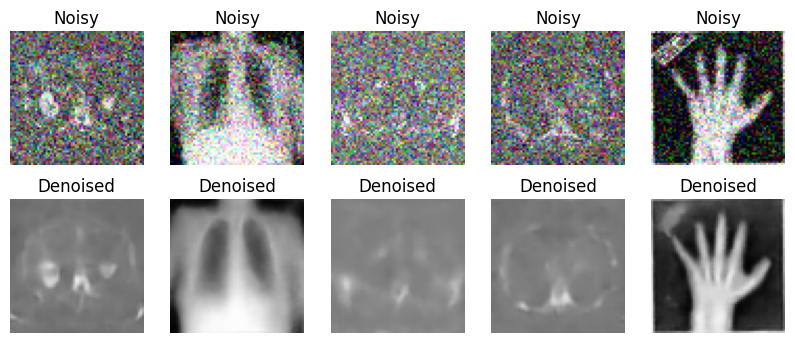

In [42]:
for batch in df.take(1):
    images = batch[0]
noise = np.random.normal(0, 0.2, images.shape)
noisy = np.clip(images + noise, 0, 1)
reconstructed = ae.predict(noisy)
plt.figure(figsize=(10, 4))
for i in range(5):
    # Noisy
    plt.subplot(2, 5, i+1)
    plt.imshow(noisy[i])
    plt.title("Noisy")
    plt.axis("off")

    # Cleaned
    plt.subplot(2, 5, i+6)
    plt.imshow(reconstructed[i])
    plt.title("Denoised")
    plt.axis("off")
plt.show()